# Tests for Wiener-SVD Unfolding Tool

- Closure test for sanity check: only use MC stat (technically don't event need this)
- Fake data tests for testing robustness of interaction uncertainties: only use MC stat and GENIE syst --

In [341]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [342]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial

# local imports
import sys
sys.path.append('../../../')
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

In [343]:
save_result = True
save_fig = save_result

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "unfolding-fake_data_tests-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/unfolding-fake_data_tests-20260325


# load dataframes

In [344]:
ret = get_ana_dfs(option="fake_data_test")
mc_hdr_df = ret['hdr']
mc_nu_df = ret['mcnu']
mc_evt_df = ret['evt']

pot_str = ret['pot_str']

Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag aa, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ab, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ac, mc_n_split: 1
mc_tot_pot: 4.562e+19
mc_pot_scale: 1.000e+00


In [345]:
# mc_evt_df["topo_categ"] = get_topo_category(mc_evt_df)
# mc_evt_df["genie_categ"] = get_genie_category(mc_evt_df)

# mc_nu_df.columns = pd.MultiIndex.from_tuples([tuple(["mc"] + list(c)) for c in mc_nu_df.columns])     # match # of column levels
# mc_nu_df["topo_categ"] = get_topo_category(mc_nu_df)
# mc_nu_df["genie_categ"] = get_genie_category(mc_nu_df)

# Choose variable

In [346]:
# var_config = VariableConfig.all_events()
var_config = VariableConfig.muon_momentum()
# var_config = VariableConfig.muon_direction()
# var_config = VariableConfig.proton_momentum()
# var_config = VariableConfig.proton_direction()
# var_config = VariableConfig.tki_del_Tp()
# var_config = VariableConfig.tki_del_alpha()
# var_config = VariableConfig.tki_del_phi()
# var_config = VariableConfig.tki_del_p()
# var_config = VariableConfig.tki_del_Tp_x()
# var_config = VariableConfig.tki_del_Tp_y()

plot_labels_hist = [var_config.var_labels[1], "Events / Bin (POT={})".format(pot_str), ""]

# Systematic Uncertainties

In [347]:
import pickle

def get_syst_unc(var_config, plot=False, save_fig=False):
    date_str = "20260220"
    mcstat_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/mcstat_syst_dict.npz", allow_pickle=True)
    mcstat_syst =dict(mcstat_syst)[var_config.var_save_name].item()['MCstat']['cov_frac']

    g4_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/g4_syst_dict.npz", allow_pickle=True)
    g4_syst =dict(g4_syst)[var_config.var_save_name].item()['G4']['cov_frac']

    flux_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/flux_syst_dict.npz", allow_pickle=True)
    flux_syst =dict(flux_syst)[var_config.var_save_name].item()['flux']['cov_frac']

    date_str = "20260222"
    cosmics_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/cosmics_syst_dict.npz", allow_pickle=True)
    cosmics_syst =dict(cosmics_syst)[var_config.var_save_name].item()['Cosmics']['cov_frac']

    date_str = "20260219"
    genie_syst = pickle.load(open(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/cov_mat_dict-{date_str}.pkl", "rb"))
    genie_syst = genie_syst[var_config.var_save_name]['genie'] 

    detector_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics_studies_detvar-20260309/detector_syst_dict.npz", allow_pickle=True)
    detector_syst =dict(detector_syst)['detector'].item()[var_config.var_save_name]['cov_frac']

    # flat uncertainties
    pot_frac_unc = 0.02
    ntargets_frac_unc = 0.01

    # flat uncertainties
    frac_uncert_total = np.zeros(len(var_config.bin_centers))
    systs      = [mcstat_syst, genie_syst, flux_syst, g4_syst, detector_syst, cosmics_syst]
    syst_names = ["MC stat.", "GENIE", "Flux", "G4", "Detector", "Cosmics"]

    for syst_name, syst in zip(syst_names, systs):
        syst_uncert = np.sqrt(np.diag(syst))

        if syst_name == "Cosmics":
            syst_uncert = np.max(syst_uncert) * np.ones(len(var_config.bin_centers))

        frac_uncert_total += syst_uncert ** 2
        if plot:
            print(syst_uncert * 1e2)
            plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

    flat_systs = [pot_frac_unc, ntargets_frac_unc]
    flat_syst_names = ["POT", "Ntargets"]
    for syst_name, syst in zip(flat_syst_names, flat_systs):
        syst_uncert = syst * np.ones(len(var_config.bin_centers))
        frac_uncert_total += syst_uncert ** 2
        if plot:
            plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

    # frac_uncert_total += detvar_syst ** 2

    frac_uncert_total = np.sqrt(frac_uncert_total)
    syst = frac_uncert_total

    if plot:
        plt.hist(var_config.bin_centers, bins=var_config.bins, weights=frac_uncert_total*1e2,    histtype="step", linewidth=2, color="k",  label="Total")

        plt.xlim(var_config.bins[0], var_config.bins[-1])
        plt.ylim(0, max(frac_uncert_total*1e2) * 1.4)

        plt.xlabel(var_config.var_labels[1])
        plt.ylabel("Uncertainty [%]")
        plt.legend(fontsize=11, ncol=3, loc="upper center")

        plt.grid(which='major', linestyle='-', linewidth=0.7, alpha=0.7)
        plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
        plt.minorticks_on()

        if save_fig:
            plt.savefig("{}/uncertainty_breakdown-{}.pdf".format(save_fig_dir, var_config.var_save_name), bbox_inches='tight')
        plt.show();

    return syst

In [348]:
var_configs = [
    VariableConfig.all_events(),
    # VariableConfig.vertex_x(),
    # VariableConfig.vertex_y(),
    # VariableConfig.vertex_z(),
    VariableConfig.muon_momentum(),
    VariableConfig.muon_direction(),
    # VariableConfig.muon_direction_x(),
    # VariableConfig.muon_direction_y(),
    VariableConfig.proton_momentum(),
    VariableConfig.proton_direction(),
    # VariableConfig.proton_direction_x(),
    # VariableConfig.proton_direction_y(),
    # VariableConfig.opening_angle(),
    VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_Tp_x(),
    VariableConfig.tki_del_Tp_y(),
    VariableConfig.tki_del_p(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
    ]

In [349]:
# for var_config in var_configs:
#     get_syst_unc(var_config, plot=True, save_fig=True)

# Unfolding

In [350]:
# --- config for Wiener-SVD unfolding ---
C_type = 2
Norm_type = 0

## Closure test (Asimov data)
- use MC signal as fake data

In [351]:
date_str = "20260220"
mcstat_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/mcstat_syst_dict.npz", allow_pickle=True)
mcstat_syst =dict(mcstat_syst)[var_config.var_save_name].item()['MCstat']['cov_frac']

In [352]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.05, 0.55]
ax_ylim_ratio = 1.6
breakdown_type = "topology"

unfolding_plotter = partial(
    overlay_hists,
    breakdown_type=breakdown_type,
    mc_df=mc_evt_df,
    data_df=mc_evt_df,
    intime_df=None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

No intime cosmics provided
No dirt cosmics provided
no syst provided


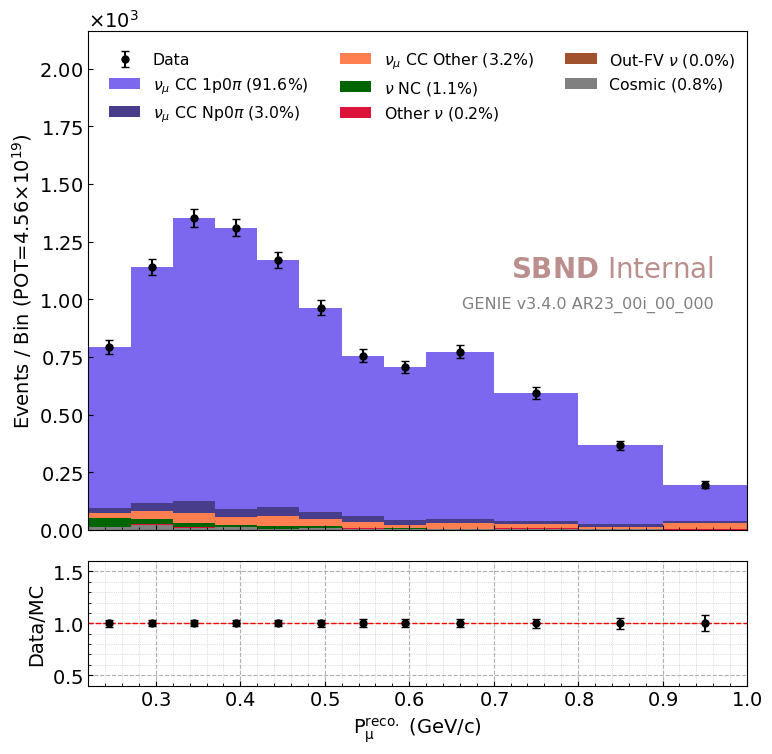

In [353]:
ret = unfolding_plotter(var_config=var_config,
                        plot_labels=plot_labels_hist,
                        syst=None,
                        save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

Diagonal ratio: 0.84
True ratio: [0.93705293 0.89726027 0.85423453 0.85094185 0.82774674 0.80225989
 0.77187948 0.75377644 0.85359116 0.84892086 0.82404692 0.78343949]


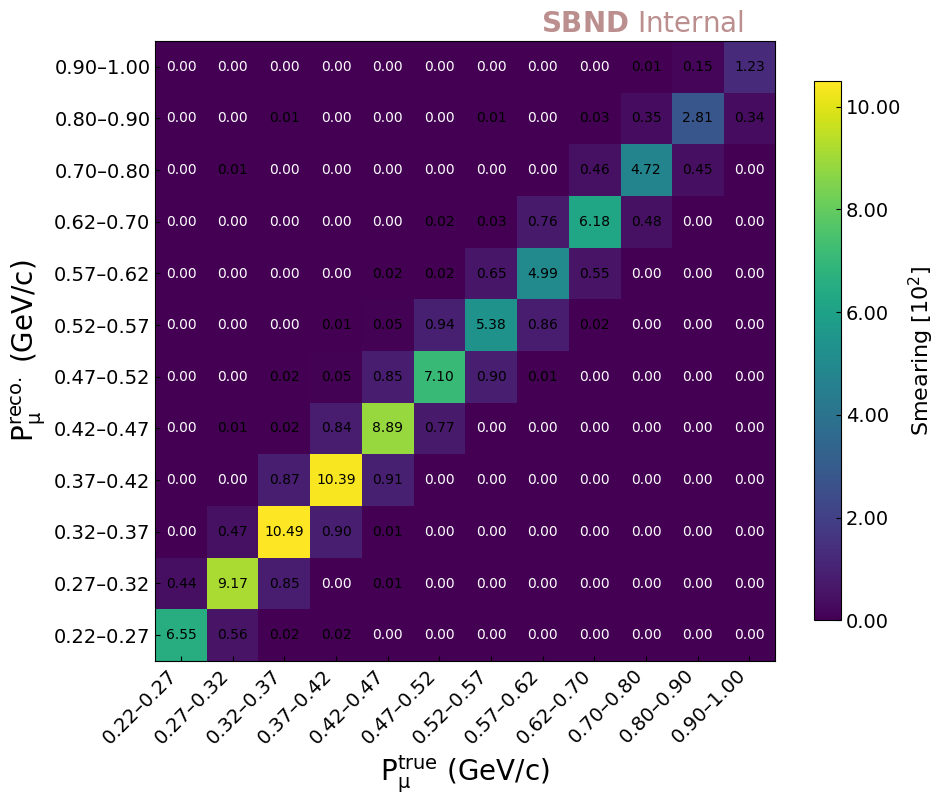

In [354]:
evtdf_signal = mc_evt_df[mc_evt_df.topo_categ == 1]
nudf_signal = mc_nu_df[mc_nu_df.topo_categ == 1]
ret = signal_hists(mc_evt_df, mc_nu_df, var_config, return_data=True, plot=False)

save_fig_name = "{}/{}-reco_vs_true".format(save_fig_dir, var_config.var_save_name)
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)

plot_heatmap(reco_vs_true, 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Smearing"],
             verbose=True,
             save_fig=save_fig, 
             cmap="viridis",
             save_name=save_fig_name)

Diagonal ratio: 0.83
True ratio: [0.91608392 0.87583572 0.88374052 0.8537387  0.84425451 0.79507279
 0.74104683 0.80096308 0.82730924 0.83687943 0.7915493  0.88489209]


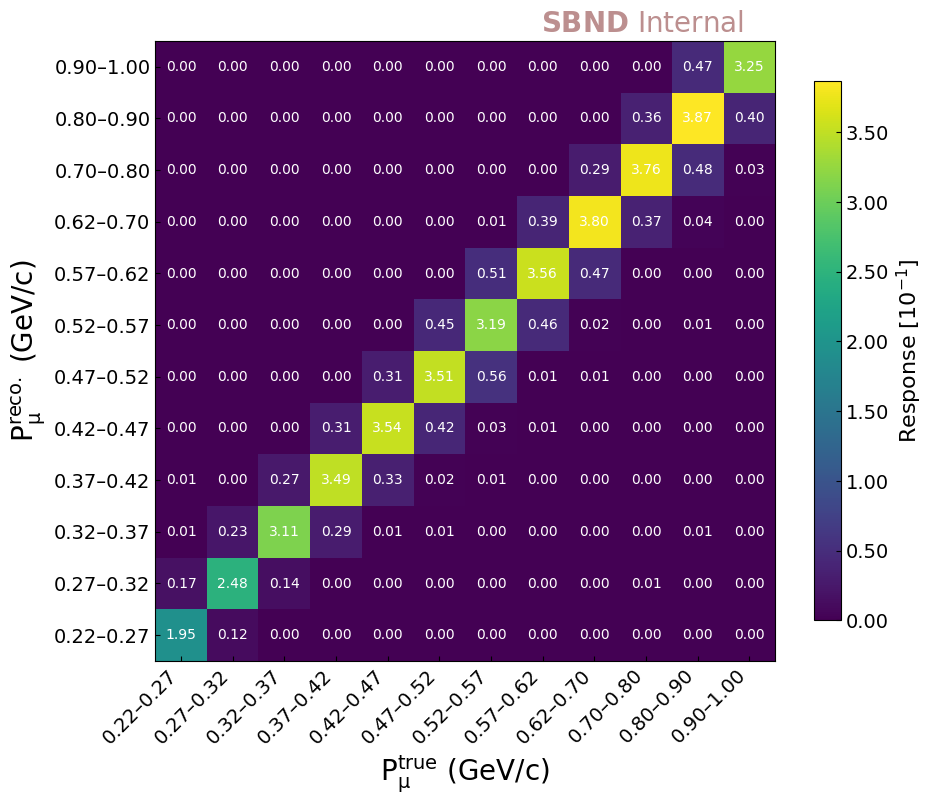

In [355]:
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]

save_fig_name = "{}/{}-response_matrix".format(save_fig_dir, var_config.var_save_name)
response = get_response_matrix(reco_vs_true, eff)

plot_heatmap(response, 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=save_fig, 
             verbose=True,
             cmap="viridis",
             save_name=save_fig_name)


In [356]:
XSEC_UNIT = 1e-38
measured = ret["nevts_sel_reco"] * XSEC_UNIT 
model    = ret["nevts_allmc"] * XSEC_UNIT
Covariance = cov_from_fraccov(mcstat_syst, ret["nevts_sel_reco"]) * XSEC_UNIT**2
unfold = WienerSVD(response, model, measured, Covariance, C_type, Norm_type)
# print(unfold.keys())
# decomp_cov = Matrix_Decomp(model, unfold['SystUnfoldCov'])

Unfolded perwidth:  [6.73054944e-34 7.37142364e-34 6.75194029e-34 5.92990770e-34
 5.02883919e-34 4.04560573e-34 3.36403930e-34 2.82521644e-34
 2.02259455e-34 1.25697832e-34 7.28050107e-35 3.76412806e-35]
Model smeared perwidth:  [6.73054944e-34 7.37142364e-34 6.75194029e-34 5.92990770e-34
 5.02883919e-34 4.04560573e-34 3.36403930e-34 2.82521644e-34
 2.02259455e-34 1.25697832e-34 7.28050107e-35 3.76412806e-35]


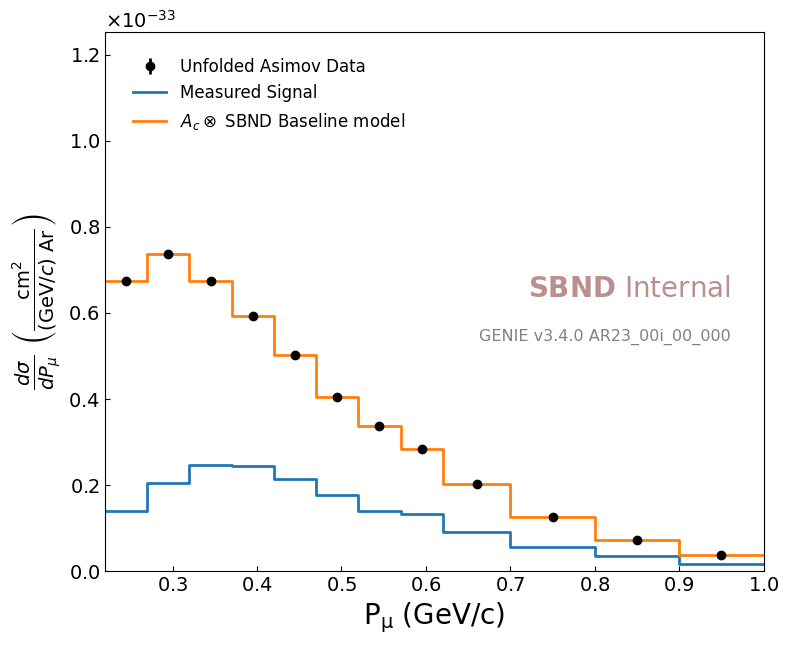

In [357]:
models = {"SBND Baseline model": model}
save_name = f"{save_fig_dir}/closure-{var_config.var_save_name}-unfolded_event_rates"

plot_unfolded_result(unfold, 
                     measured, 
                     models, 
                     var_config,
                     save_fig=save_fig, 
                     save_name=save_name,
                     closure_test=True)

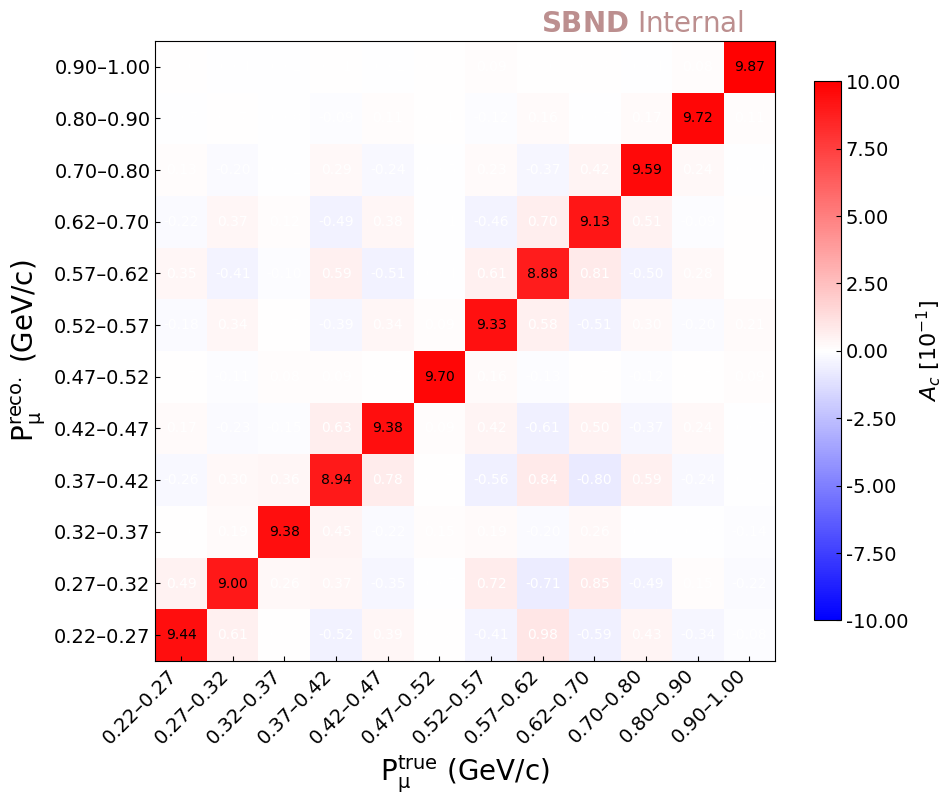

In [359]:
save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "closure_test")
plot_heatmap(unfold["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

## Fake Data Tests

- use alternate MC as fake data

In [291]:
Norm_type = 0
C_type = 2

In [292]:
date_str = "20260219"
genie_syst = pickle.load(open(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/cov_mat_dict-{date_str}.pkl", "rb"))
genie_syst = genie_syst[var_config.var_save_name]['genie'] 
syst = np.sqrt(np.diag(genie_syst))

# use only stat unc and xsec unc for fake data tests
covariance_frac = genie_syst + mcstat_syst

In [293]:
unfolded_plot_labels = [var_config.var_labels[0], var_config.xsec_label]
smearmat_plot_labels = [var_config.var_labels[2], var_config.var_labels[1]]

In [294]:
# # TODO: calculate this when making dfs
# mc_evt_df[("mu","pfp","trk","truth","p","dir","z")] = mc_evt_df.mu.pfp.trk.truth.p.genp.z / mc_evt_df.mu.pfp.trk.truth.p.totp

In [295]:
from analysis_village.numucc_1p0pi.fake_data_test_configs import FakeDataWeights

fake_weight_obj = FakeDataWeights(mc_evt_df, mc_nu_df, var_config)

test_configs = {
    "mec_test": [0.5, "MEC Scale"],
    "qe_test": [1.2, "QE Scale"],
    # "np_test": 2,
    # "sig_test": 1.2,
    "q2_test_alpha_0.3": [0.3, "$Q^2$ tilt"],
    "costh_weight_scale_0.7": [0.7, "Forward Muon Scale"],
    "proton_P_tilt_alpha_0.3": [0.3, "Proton Momentum Tilt"],
}

# test_name = "bump_0.6_0.0015_0.002"
# bump_pos = -0.3
# bump_width = 0.002
# bump_height = 0.03
# weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, bump_pos=bump_pos, bump_width=bump_width, bump_height=bump_height)

No intime cosmics provided
No dirt cosmics provided


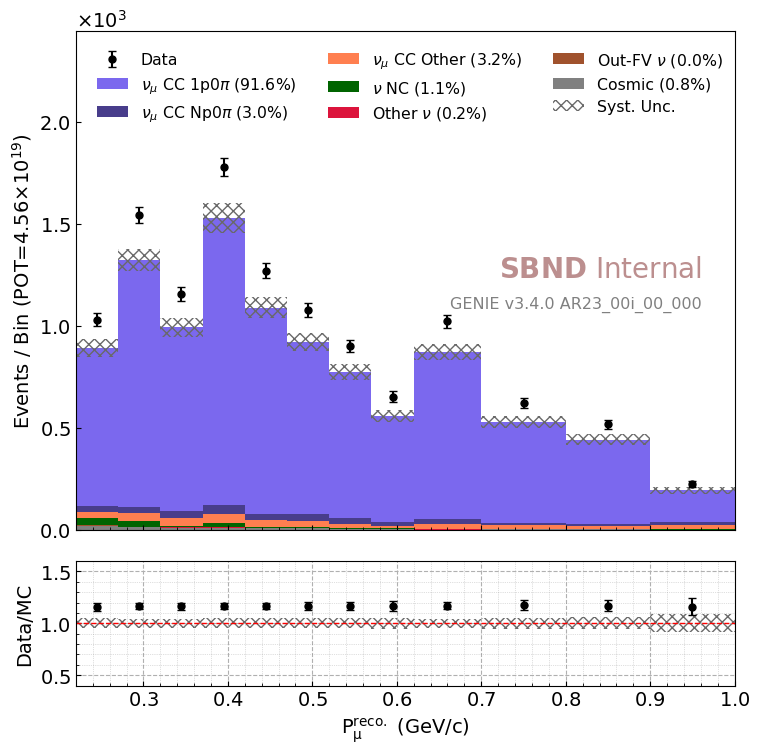

Unfolded perwidth:  [7.95046387e-34 8.52241240e-34 8.02479473e-34 6.84841171e-34
 5.78325797e-34 4.82814045e-34 3.83790592e-34 3.42428518e-34
 2.31354375e-34 1.48010186e-34 8.48620072e-35 4.52695154e-35]
Model smeared perwidth:  [6.76453211e-34 7.20334270e-34 6.79106218e-34 5.81910545e-34
 4.90830143e-34 4.08070981e-34 3.25666704e-34 2.92041873e-34
 1.95385802e-34 1.24962240e-34 7.21188882e-35 3.75734936e-35]
Unfolded perwidth:  [7.95046387e-34 8.52241240e-34 8.02479473e-34 6.84841171e-34
 5.78325797e-34 4.82814045e-34 3.83790592e-34 3.42428518e-34
 2.31354375e-34 1.48010186e-34 8.48620072e-35 4.52695154e-35]
Model smeared perwidth:  [7.85294991e-34 8.38510153e-34 7.91656400e-34 6.78775251e-34
 5.72488411e-34 4.75760680e-34 3.79351302e-34 3.40266968e-34
 2.28295326e-34 1.46100370e-34 8.43204171e-35 4.37825129e-35]


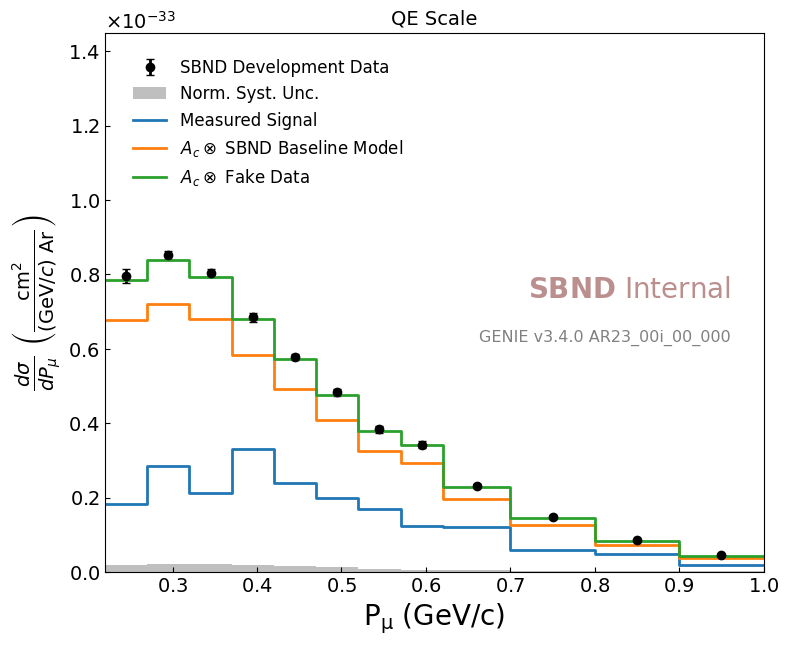

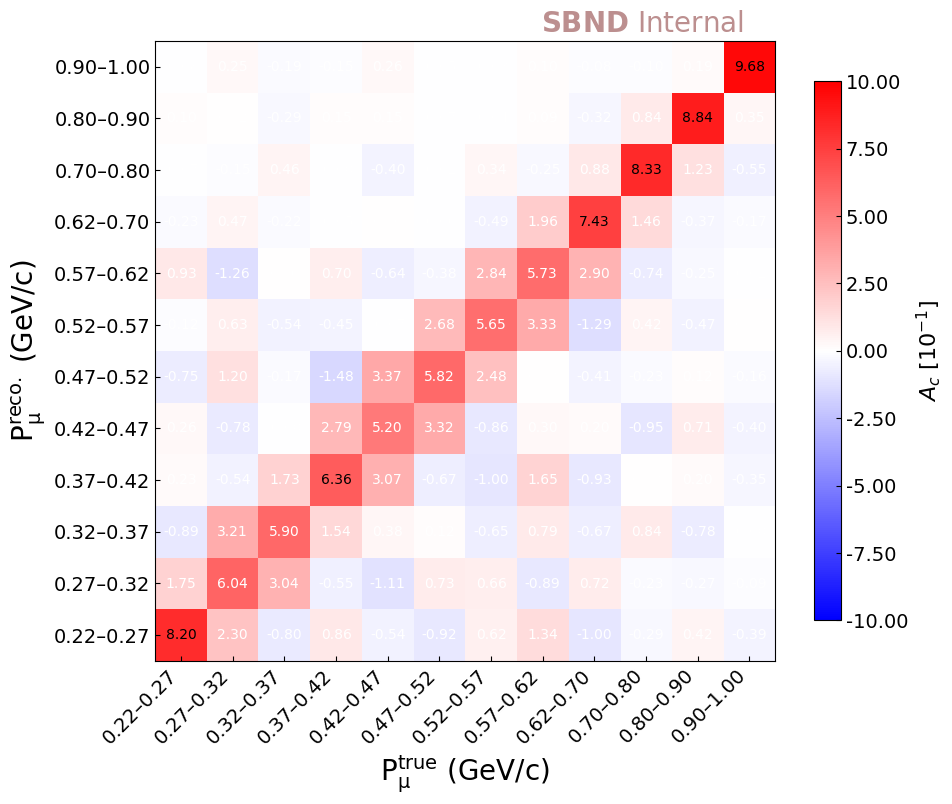

In [330]:
# for test_name, configs in test_configs.items():

test_name = "qe_test"
configs = [1.2, "QE Scale"]

weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, scale_factor=configs[0])

fakedata_evt_df = mc_evt_df.copy()
fakedata_evt_df["pot_weight"] *= weights_fake_data

evtdf_signal = mc_evt_df[mc_evt_df.topo_categ == 1]
nudf_signal = mc_nu_df[mc_nu_df.topo_categ == 1]
ret = signal_hists(mc_evt_df, mc_nu_df, var_config, return_data=True, plot=False)

nevts_fakedata_reco, _ = np.histogram(ret["var_allsel_reco"], bins=var_config.bins, weights=weights_fake_data)
nevts_nomdata_signal_truth, _ = np.histogram(ret["var_allmc"], bins=var_config.bins)
nevts_fakedata_signal_truth, _ = np.histogram(ret["var_allmc"], bins=var_config.bins, weights=weight_fakedata_signal_truth)

covariance = cov_from_fraccov(covariance_frac, ret["nevts_sel_reco"]) * XSEC_UNIT**2

# fig, ax = plt.subplots()
# plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_fakedata_reco, histtype="step", label="all selected events")
# plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_nomdata_signal_truth, histtype="step", label="nominal MC, all signal")
# plt.hist(var_config.bin_centers, var_config.bins, weights=nevts_fakedata_signal_truth, histtype="step", label="alternative MC, all signal")
# plt.legend()
# plt.show();

ret = overlay_hists(breakdown_type=breakdown_type,
                mc_df=mc_evt_df,
                data_df=fakedata_evt_df,
                intime_df=None,
                var_config=var_config,
                plot_labels=plot_labels_hist,
                ax_ylim_ratio=ax_ylim_ratio,
                ratio=ratio,
                syst=syst,
                textloc=textloc,
                approval=approval,
                save_fig=save_fig, 
                save_name=path.join(save_fig_dir, "{}_{}.png".format(var_config.var_save_name, breakdown_type)))

measured = (ret["total_data"] - ret["total_mc_bkgd"]) * XSEC_UNIT
model = nevts_nomdata_signal_truth * XSEC_UNIT

unfold = WienerSVD(response, model, measured, covariance, C_type, Norm_type)

models = {"SBND Baseline Model": model, 
        "Fake Data": nevts_fakedata_signal_truth * XSEC_UNIT}

save_fig_name = f"{save_fig_dir}/{test_name}-{var_config.var_save_name}-unfolded_event_rates"
plot_unfolded_result(unfold, 
                measured, 
                models, 
                var_config,
                xsec_unit=XSEC_UNIT,
                plot_labels=["", "", configs[1]],
                save_fig=save_fig, 
                save_name=save_fig_name,
                data=False,
                closure_test=False)

save_fig_name = f"{save_fig_dir}/{test_name}-{var_config.var_save_name}-add_smear"
plot_heatmap(unfold["AddSmear"], 
        var_config.bins, 
        plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
        save_fig=save_fig, 
        save_name=save_fig_name)

In [ ]:
# measured = (ret["total_data"] - ret["total_mc_bkgd"]) * XSEC_UNIT
# model = nevts_nomdata_signal_truth * XSEC_UNIT

# for Norm_type in [0, 0.5, 1]:
#     for C_type in [0, 1, 2]:
#         unfold = WienerSVD(response, model, measured, covariance, C_type, Norm_type)

#         models = {"SBND Baseline Model": model, 
#                 "Fake Data": nevts_fakedata_signal_truth * XSEC_UNIT}

#         # save_name = "{}/{}-{}-unfolded_event_rates.pdf".format(save_fig_dir, test_name, var_config.var_save_name)
#         save_fig_name = f"{save_fig_dir}/{test_name}-{var_config.var_save_name}-{Norm_type}-{C_type}-unfolded_event_rates"
#         plot_unfolded_result(unfold, 
#                             measured, 
#                             models, 
#                             var_config,
#                             plot_labels=["", "", f"Norm: {Norm_type}, C: {C_type}"],
#                             save_fig=save_fig, 
#                             save_name=save_fig_name,
#                             closure_test=False)

#         # save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "closure_test")
#         save_fig_name = f"{save_fig_dir}/{test_name}-{var_config.var_save_name}-{Norm_type}-{C_type}-add_smear"
#         plot_heatmap(unfold["AddSmear"], 
#                     var_config.bins, 
#                     plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
#                     save_fig=save_fig, 
#                     save_name=save_fig_name)

#         save_fig_name = f"{save_fig_dir}/{test_name}-{var_config.var_save_name}-{Norm_type}-{C_type}-C0"
#         plot_heatmap(unfold["C0"], 
#                     var_config.bins, 
#                     plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$C_0$"],
#                     save_fig=save_fig, 
#                     save_name=save_fig_name)

# Check distributions for fake data

## $Q^2$ reweight

In [ ]:
fake_weight_obj = FakeDataWeights(mc_evt_df, mc_nu_df, var_config)
Q2 = 2 * mc_evt_df.mc.E * mc_evt_df.mu.pfp.trk.truth.p.startE * (1 - mc_evt_df.mu.pfp.trk.truth.p.dir.z)
test_name = "q2_test_alpha_0.3"
alpha = 0.3
weights_fake_data, weight_fakedata_signal_truth = fake_weight_obj.get_weights(test_name, alpha=alpha)

plt.hist(Q2, bins=var_config.bins, histtype="step", color="black", label="Nominal")
plt.hist(Q2, bins=var_config.bins, weights=weights_fake_data, histtype="step", color="red", label="Reweighted, $\\alpha=${}".format(alpha))
plt.xlabel("$Q^2$")
plt.ylabel("Events / Bin")
plt.legend()
if save_fig:
    plt.savefig("{}/Q2_reweight_{}.pdf".format(save_fig_dir, alpha), bbox_inches="tight")
plt.show();

# Generator Comparisons

In [ ]:
mcstat_syst = np.load("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-20260216/mcstat_syst_dict.npz", allow_pickle=True)
mcstat_syst =dict(mcstat_syst)[var_config.var_save_name].item()['MCstat']['cov_frac']

g4_syst = np.load("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-20260216/g4_syst_dict.npz", allow_pickle=True)
g4_syst =dict(g4_syst)[var_config.var_save_name].item()['G4']['cov_frac']

cosmics_syst = np.load("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-20260216/cosmics_syst_dict.npz", allow_pickle=True)
cosmics_syst =dict(cosmics_syst)[var_config.var_save_name].item()['Cosmics']['cov_frac']

flux_syst = np.load("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-20260219/flux_syst_dict.npz", allow_pickle=True)
flux_syst = dict(flux_syst)[var_config.var_save_name].item()['flux']['cov_frac']

genie_syst = pickle.load(open("/exp/sbnd/data/users/munjung/plots/numucc1p0pi/cov_mat_dict-20260219.pkl", "rb"))
genie_syst = genie_syst[var_config.var_save_name]['genie'] 

# detvar_syst = pickle.load(open("/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts/det_unc_dict-20260216.pkl", "rb"))
# detvar_syst = detvar_syst[var_config.var_save_name]['detvar']

# detvar_syst = pickle.load(open("/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts/det_unc_dict-20260216.pkl", "rb"))
# detvar_syst = np.sqrt(detvar_syst[var_config.var_save_name]['ccal']**2 \
#     + detvar_syst[var_config.var_save_name]['alpha']**2 \
#     + detvar_syst[var_config.var_save_name]['beta']**2 \
#     + detvar_syst[var_config.var_save_name]['R']**2) / 2.


# flat uncertainties
pot_frac_unc = 0.02
ntargets_frac_unc = 0.01

frac_uncert_total = np.zeros(len(var_config.bin_centers))

# systs with covariance
systs      = [mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst] # , detvar_syst]
syst_names = ["MC stat.", "GENIE", "Flux", "G4", "Cosmics"] # , "Detector"]
# flat systs
flat_systs = [pot_frac_unc, ntargets_frac_unc]
flat_syst_names = ["POT", "Ntargets"]

for syst_name, syst in zip(syst_names, systs):
    syst_uncert = np.sqrt(np.diag(syst))
    # if syst_name == "Cosmics":
    #     # set all values to the max value
    #     syst_uncert = np.max(syst_uncert) * np.ones(len(var_config.bin_centers))
    frac_uncert_total += syst_uncert ** 2
    print(syst_name, syst_uncert)
    plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

# frac_uncert_total += detvar_syst ** 2
# print(detvar_syst)
# plt.hist(var_config.bin_centers, bins=var_config.bins, weights=detvar_syst * 1e2,   histtype="step", linewidth=2, label="Detector")

for syst_name, syst in zip(flat_syst_names, flat_systs):
    syst_uncert = syst * np.ones(len(var_config.bin_centers))
    frac_uncert_total += syst_uncert ** 2
    plt.hist(var_config.bin_centers, bins=var_config.bins, weights=syst_uncert * 1e2,   histtype="step", linewidth=2, label=syst_name)

frac_uncert_total = np.sqrt(frac_uncert_total)
plt.hist(var_config.bin_centers, bins=var_config.bins, weights=frac_uncert_total * 1e2,    histtype="step", linewidth=2, color="k",  label="Total")
plt.legend()
print("total", frac_uncert_total)

In [ ]:
with open('/exp/sbnd/app/users/munjung/xsec/cafpyana/analysis_village/numucc1p0pi/nevts_dict.pkl', 'rb') as f:
    nevts_dict = pickle.load(f)

In [ ]:
cov_matrix = mcstat_syst + genie_syst + flux_syst + g4_syst + cosmics_syst
# add flat uncertainties
cov_matrix += np.diag([0.02 ** 2] * cov_matrix.shape[0])
plt.imshow(cov_matrix)
plt.colorbar()
plt.show();

frac_unc = np.sqrt(np.diag(cov_matrix))
frac_unc

In [ ]:
for genname in ["GENIE AR23", "GENIE AR25", "GiBUU", "NuWro", "NEUT"]:
    bin_centers = var_config.bin_centers
    bins = var_config.bins

    if genname == "GENIE AR23":
        plt.errorbar(bin_centers, nevts_dict[genname], yerr=frac_unc * nevts_dict[genname], fmt="o", color="black")

    else:
    # get chi2 with GENIE
        total_cov = cov_from_fraccov(cov_matrix, nevts_dict["GENIE AR23"])
        this_chi2, this_pval = get_chi2(nevts_dict[genname], nevts_dict["GENIE AR23"], total_cov)
        label = f"{genname} ($\\chi^2/ndof$={this_chi2:.2f} / {len(bin_centers)-1})"
        plt.hist(bin_centers, bins=bins, weights=nevts_dict[genname], histtype="step", label=label)


plt.xlabel(var_config.var_labels[0])
plt.ylabel("Events / Bin")
plt.legend(fontsize=12)
plt.show();

# Regularization Demos

In [327]:
from scipy.stats import norm

In [317]:
save_fig = True

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "regularization-demo-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/regularization-demo-20260325


## Generic Case

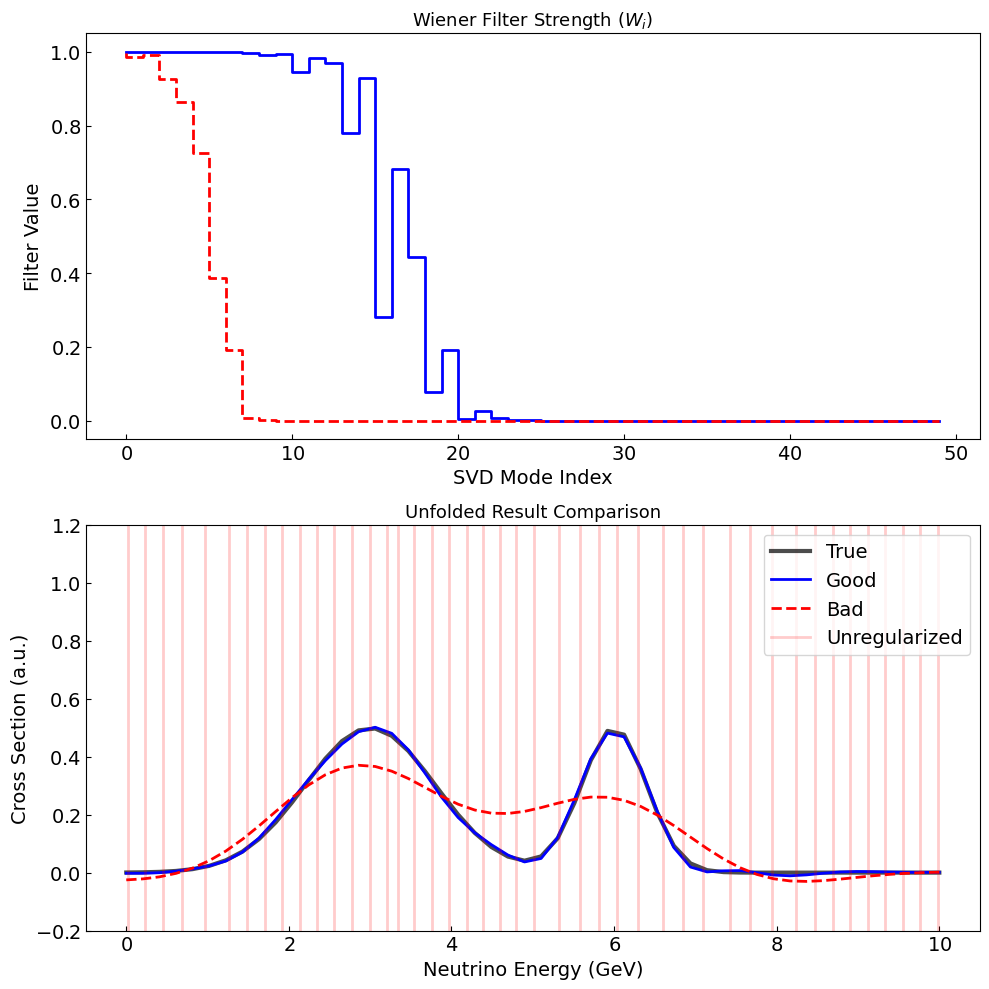

In [ ]:
def run_unfolding_study(n_bins=50, resolution=0.3, flat_eff=True, noise_level=0.02):

    # two gaussian peaks
    x_axis = np.linspace(0, 10, n_bins)
    x_true = norm.pdf(x_axis, loc=3, scale=0.8) + 0.5 * norm.pdf(x_axis, loc=6, scale=0.4)
    
    # smearing matrix with eff.
    R = np.zeros((n_bins, n_bins))
    for j in range(n_bins):
        eff = 0.9 if flat_eff else 0.9 * np.exp(-0.05 * (x_axis[j]-5)**2)
        R[:, j] = norm.pdf(x_axis, loc=x_axis[j], scale=resolution) * eff
    R /= (R.sum(axis=0) + 1e-9)

    U, S, Vt = np.linalg.svd(R)
    d = U.T @ (R @ x_true)
    n_i_squared = np.full(n_bins, noise_level**2)
    
    snr_i = (S * d)**2 / n_i_squared
    wf = snr_i / (snr_i + 1)
    
    y_meas = (R @ x_true) + np.random.normal(0, noise_level, n_bins)
    
    x_reg = Vt.T @ np.diag(wf/S) @ U.T @ y_meas
    x_unreg = Vt.T @ np.diag(1/S) @ U.T @ y_meas
    return x_axis, x_true, wf, x_unreg, x_reg

x, x_true, wf_good, x_unreg_good, x_reg_good = run_unfolding_study(resolution=0.2, noise_level=0.01)
_, _, wf_poor, x_unreg_poor, x_reg_poor = run_unfolding_study(resolution=0.8, flat_eff=False, noise_level=0.05)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)

ax1.step(range(len(wf_good)), wf_good, label='Good', color='blue', lw=2)
ax1.step(range(len(wf_poor)), wf_poor, label='Bad', color='red', ls='--', lw=2)
ax1.set_title("Wiener Filter Strength ($W_i$)", fontsize=13)
ax1.set_ylabel("Filter Value")
ax1.set_xlabel("SVD Mode Index")

ax2.plot(x, x_true, color='black', label='True', lw=3, alpha=0.7)
ax2.plot(x, x_reg_good, color='blue', label='Good', lw=2)
ax2.plot(x, x_reg_poor, color='red', label='Bad', ls='--', lw=2)

ax2.plot(x, x_unreg_poor, color='red', alpha=0.2, label='Unregularized')

ax2.set_title("Unfolded Result Comparison", fontsize=13)
ax2.set_ylabel("Cross Section (a.u.)")
ax2.set_xlabel("Neutrino Energy (GeV)")
ax2.set_ylim(-0.2, 1.2) 
ax2.legend()

plt.tight_layout()
plt.show()

## For a Fake Data Study

In [360]:
save_fig = False

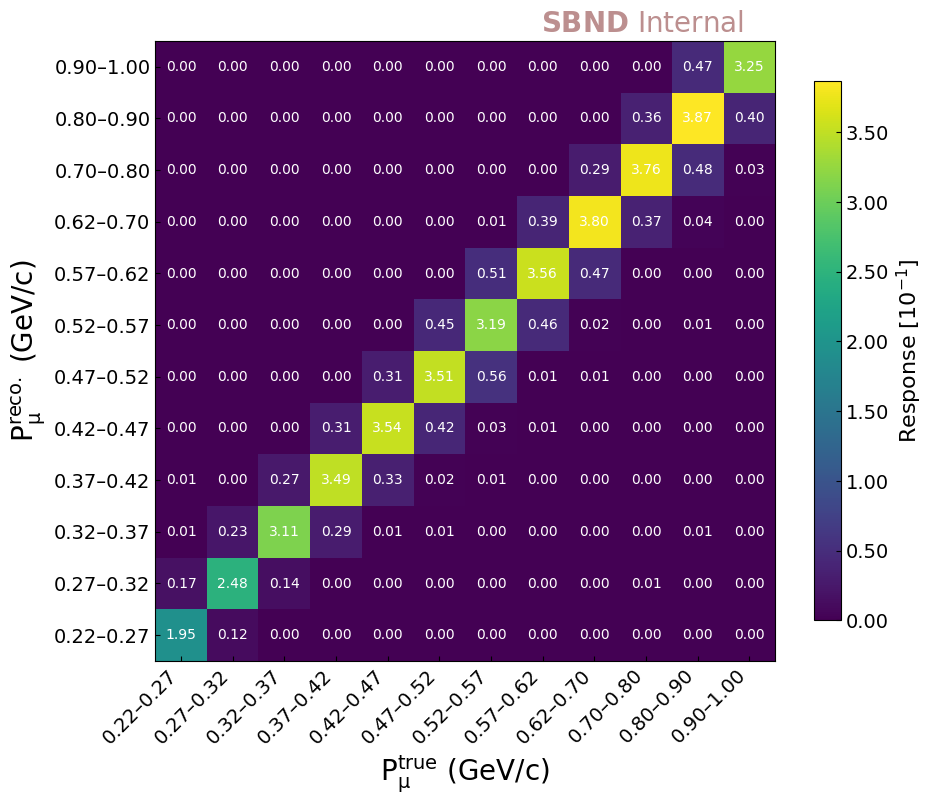

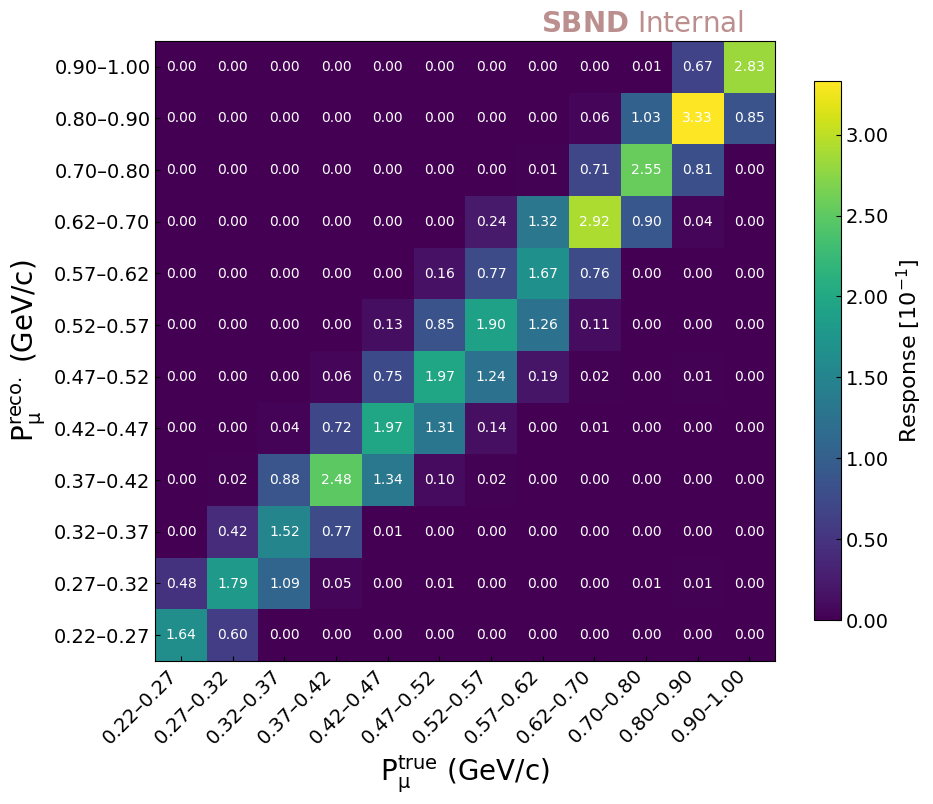

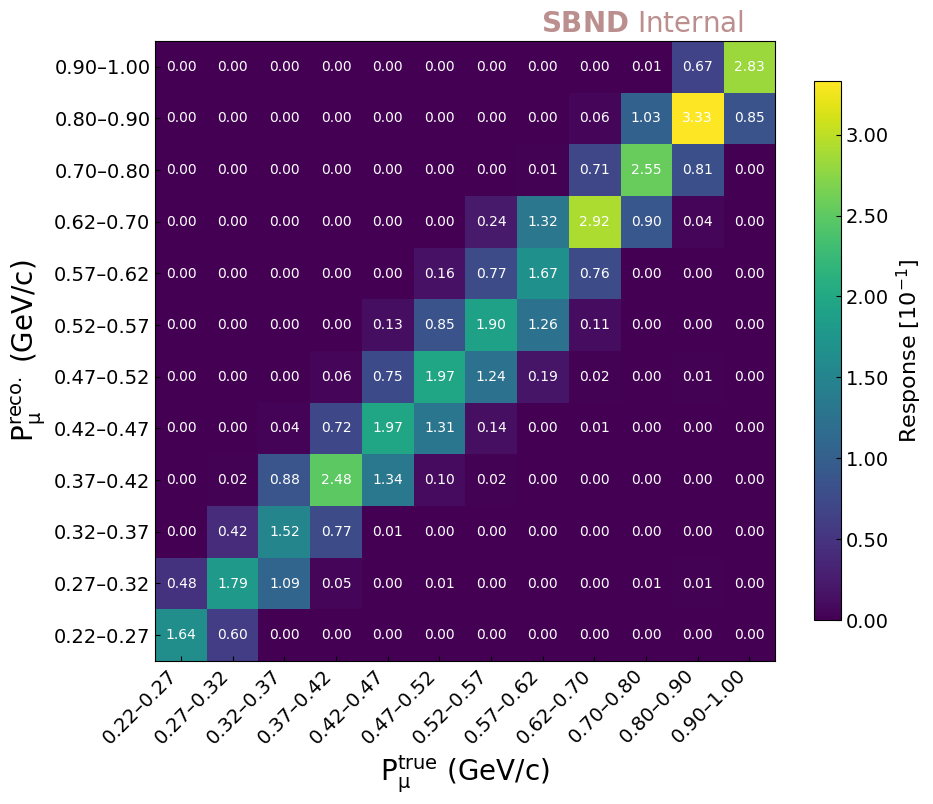

In [361]:
var_config = VariableConfig.muon_momentum()
ret = signal_hists(mc_evt_df, mc_nu_df, var_config, return_data=True, plot=False)
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)
response = get_response_matrix(reco_vs_true, eff)

save_fig_name = "{}/{}-response_matrix-range".format(save_fig_dir, var_config.var_save_name)
plot_heatmap(response, 
             var_config.bins, 
             cmap="viridis",
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=save_fig, 
             save_name=save_fig_name)

covariance = cov_from_fraccov(covariance_frac, ret["nevts_sel_reco"]) * XSEC_UNIT**2
ret_nominal = WienerSVD(response, model, measured, covariance, C_type, Norm_type)

ret = signal_hists(mc_evt_df, mc_nu_df, VariableConfig.muon_momentum_mcs(), return_data=True, plot=False)
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)

response = get_response_matrix(reco_vs_true, eff)

save_fig_name = "{}/{}-response_matrix-mcs".format(save_fig_dir, var_config.var_save_name)
plot_heatmap(response, 
             var_config.bins, 
             cmap="viridis",
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=save_fig, 
             save_name=save_fig_name)

covariance = cov_from_fraccov(covariance_frac*6.0, ret["nevts_sel_reco"]) * XSEC_UNIT**2
ret_poor = WienerSVD(response, model, measured, covariance, C_type, Norm_type)

ret = signal_hists(mc_evt_df, mc_nu_df, VariableConfig.muon_momentum_mcs(), return_data=True, plot=False)
eff = ret["nevts_sel_truth"] / ret["nevts_allmc"]
reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                    ret["var_sel_reco"], 
                                    weights=ret["wgt_sel_reco"],
                                    bins=var_config.bins)
response = get_response_matrix(reco_vs_true, eff)

plot_heatmap(response, 
             var_config.bins, 
             cmap="viridis",
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "Response"],
             save_fig=False, 
             save_name=None)

covariance = cov_from_fraccov(covariance_frac*6.0, ret["nevts_sel_reco"]) * XSEC_UNIT**2
ret_poor_2 = WienerSVD(response, model, measured, covariance, C_type, 0.5)

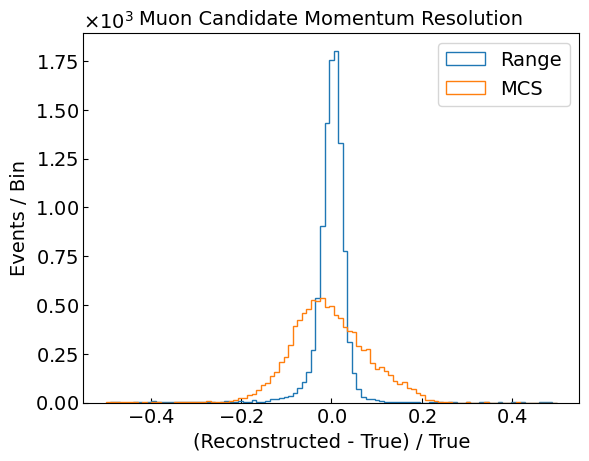

In [362]:
labels = ["Range", "MCS"]
for i, var_config in enumerate([VariableConfig.muon_momentum(), VariableConfig.muon_momentum_mcs()]):
    frac_unc = (mc_evt_df[var_config.var_evt_reco_col] - mc_evt_df[var_config.var_evt_truth_col]) / mc_evt_df[var_config.var_evt_truth_col]
    bins = np.linspace(-0.5, 0.5, 100)
    plt.hist(frac_unc, bins=bins, histtype="step", label=labels[i])
plt.legend()
plt.xlabel("(Reconstructed - True) / True")
plt.ylabel("Events / Bin")
plt.title("Muon Candidate Momentum Resolution")

save_fig_name = "{}/{}-frac_unc.png".format(save_fig_dir, var_config.var_save_name)
plt.savefig(save_fig_name, bbox_inches="tight", dpi=300)
plt.show();

KeyError: 'Fake Data'

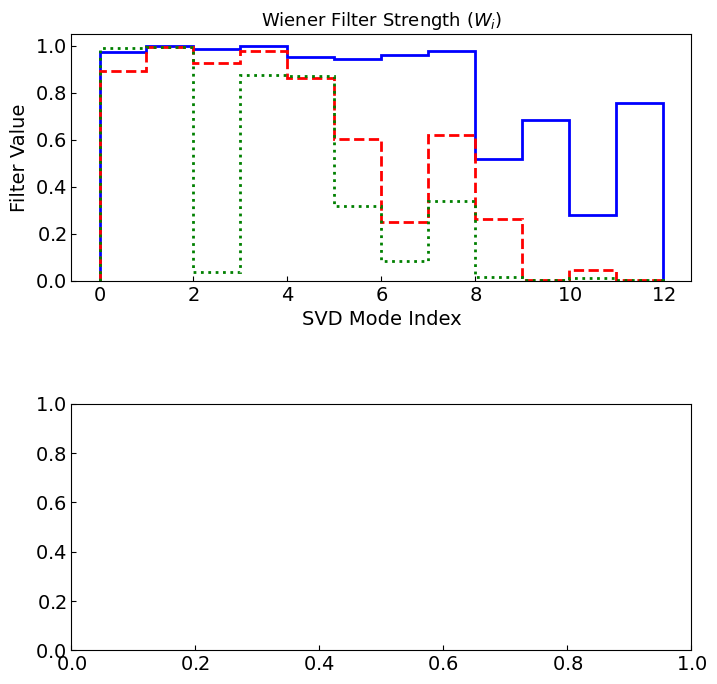

In [363]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=False)
fig.subplots_adjust(hspace=0.5)

bins = np.array(range(len(var_config.bins)))
bin_centers = (bins[1:] + bins[:-1]) / 2
ax1.hist(bin_centers, bins=bins, weights=ret_nominal['WF'], histtype="step", label='Range', color='blue', lw=2)
ax1.hist(bin_centers, bins=bins, weights=ret_poor['WF'], histtype="step", label='MCS', color='red', ls='--', lw=2)
ax1.hist(bin_centers, bins=bins, weights=ret_poor_2['WF'], histtype="step", label='MCS (strong regularization)', color='green', ls=':', lw=2)
ax1.set_title("Wiener Filter Strength ($W_i$)", fontsize=13)
ax1.set_ylabel("Filter Value")
ax1.set_xlabel("SVD Mode Index")

bin_widths = var_config.bins[1:] - var_config.bins[:-1]
ax2.plot(var_config.bin_centers, 1e33 * models["Fake Data"] / bin_widths, color='black', label='True Model', lw=3, alpha=0.7)
ax2.plot(var_config.bin_centers, 1e33 * ret_nominal['unfold'] / bin_widths, color='blue', label='Unfolded: Range', lw=2)
ax2.plot(var_config.bin_centers, 1e33 * ret_poor['unfold'] / bin_widths, color='red', label='Unfolded: MCS', ls='--', lw=2)
ax2.plot(var_config.bin_centers, 1e33 * ret_poor_2['unfold'] / bin_widths, color='green', label='Unfolded: MCS (strong regularization)', ls=':', lw=2)

ax2.set_ylabel("Cross Section (a.u.)")
ax2.set_xlabel(var_config.var_labels[0])
ax2.legend()

plt.tight_layout()

save_fig_name = "{}/{}-unfolded_result_comparison.png".format(save_fig_dir, var_config.var_save_name)
plt.savefig(save_fig_name, bbox_inches="tight", dpi=300)
plt.show()

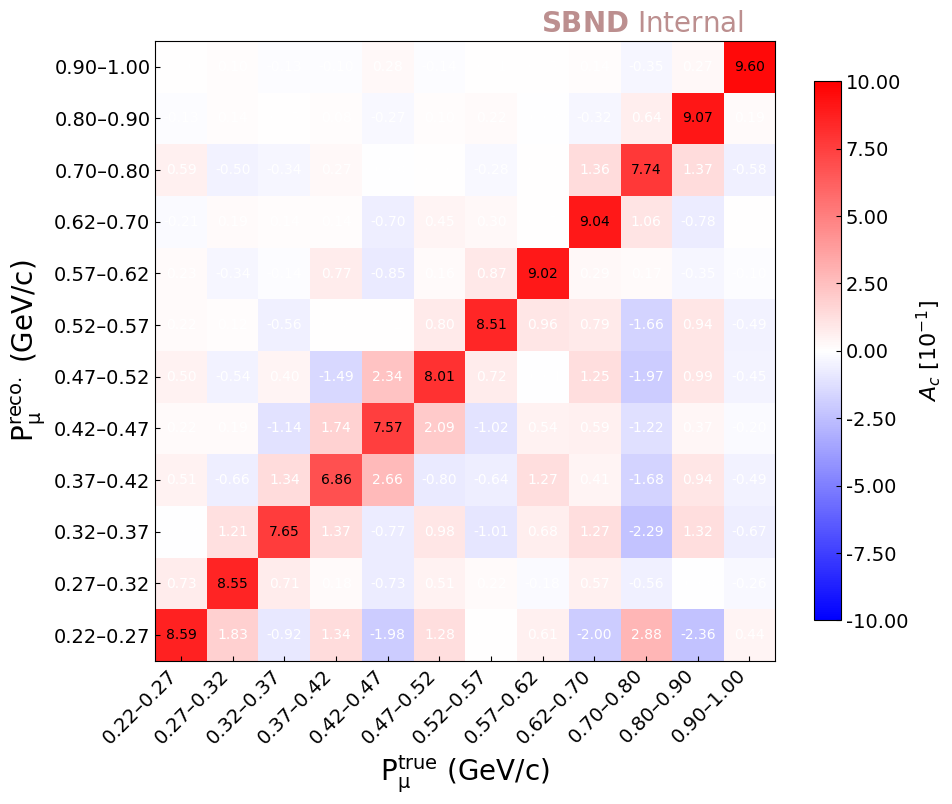

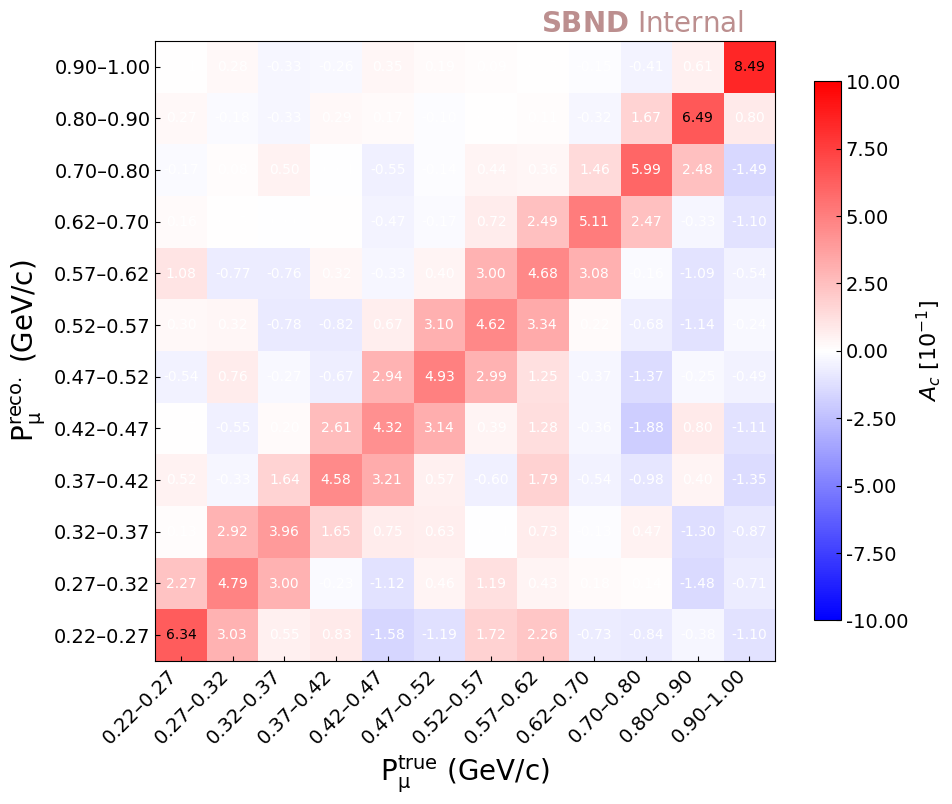

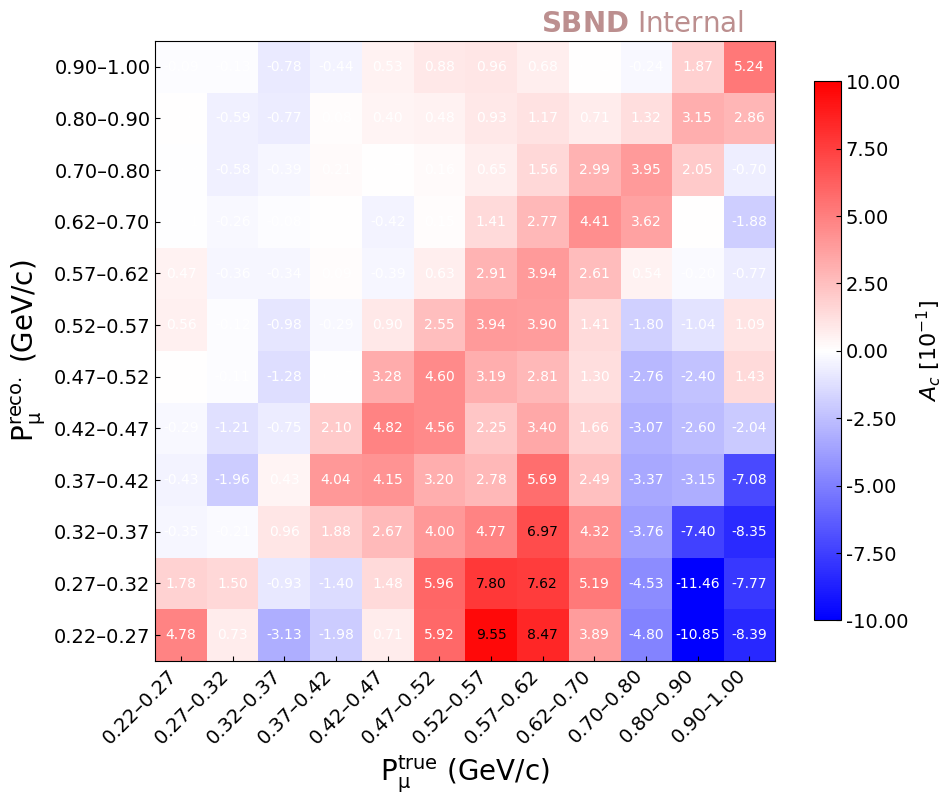

In [ ]:
save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "AddSmear_range")
plot_heatmap(ret_nominal["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "AddSmear_mcs")
plot_heatmap(ret_poor["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

save_fig_name = "{}/{}-{}-add_smear".format(save_fig_dir, var_config.var_save_name, "AddSmear_mcs_strong_reg")
plot_heatmap(ret_poor_2["AddSmear"], 
             var_config.bins, 
             plot_labels=[var_config.var_labels[2], var_config.var_labels[1], "$A_c$"],
             save_fig=save_fig, 
             save_name=save_fig_name)

In [325]:
save_fig_dir

'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/regularization-demo-20260325'